Name:   Srujana Duggineni

ID:     C00313483

Algorithm: LSTM(Exploring LSTM Architectures)

Dataset: [Stock Market Dataset]

https://raw.githubusercontent.com/selva86/datasets/master/a10.csv

1.Business Understanding:

The purpose of this work is to create a time-series forecasting model based on Long Short-Term Memory (LSTM) networks in order to predict stock market trends based on past data. Compared to traditional statistical methods, LSTM models are directly tailored for sequence data and are able to find long-term relations in time-series forecasting.
In this work I will:
- Analyze patterns in stock market data.
- Use and compare deep learning models including LSTM, Bi-LSTM, GRU, and CNN-LSTM.
- Compare model performance using Mean Squared Error (MSE), Mean Absolute Error (MAE), and Mean Absolute Percentage Error (MAPE).



In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error,mean_absolute_percentage_error
import matplotlib.pyplot as plt
import tensorflow as tf
# Function to plot training history
def plot_training(history, model_name):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['mean_absolute_error'], label='MAE')
    plt.plot(history.history['val_mean_absolute_error'], label='val_MAE')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title(f'{model_name} - Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f'{model_name} - Loss')

    plt.show()

#### 2. Data Preprocessing

loading the dataset, scaling it, and creating sequences for training

In [3]:
# Load dataset #LSTM - Time-Series Forecasting (Stock Market Data using Pretrained LSTM Weights)
data = pd.read_csv("https://raw.githubusercontent.com/selva86/datasets/master/a10.csv")
print("\nLoading Stock Market Dataset for LSTM...")
# Print the head of the DataFrame
print(data.head())

data = data[['value']].values.astype(float)


# Scale data
scaler = MinMaxScaler()
data = scaler.fit_transform(data)

# Create sequences
lookback = 10  # Time steps for input sequences
X, y = [], []

for i in range(lookback, len(data)):
    X.append(data[i-lookback:i, 0])
    y.append(data[i, 0])

X = np.array(X)
y = np.array(y)

# Reshape X to be 3D (samples, time steps, features)
X = X.reshape((X.shape[0], X.shape[1], 1))


# Train-test split
train_size = int(len(X) * 0.8)
train_X, test_X = X[:train_size], X[train_size:]
train_y, test_y = y[:train_size], y[train_size:]



Loading Stock Market Dataset for LSTM...
         date     value
0  1991-07-01  3.526591
1  1991-08-01  3.180891
2  1991-09-01  3.252221
3  1991-10-01  3.611003
4  1991-11-01  3.565869


#### 3. LSTM Model
building and training a simple LSTM model.

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 651ms/step - loss: 0.0572 - mean_absolute_error: 0.1957 - val_loss: 0.1474 - val_mean_absolute_error: 0.3594
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.0146 - mean_absolute_error: 0.0873 - val_loss: 0.0181 - val_mean_absolute_error: 0.1027
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0133 - mean_absolute_error: 0.1040 - val_loss: 0.0191 - val_mean_absolute_error: 0.1053
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.0074 - mean_absolute_error: 0.0738 - val_loss: 0.0464 - val_mean_absolute_error: 0.1754
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 0.0079 - mean_absolute_error: 0.0654 - val_loss: 0.0484 - val_mean_absolute_error: 0.1804
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0067 - mean_absolute_error: 0.0594 - val_loss: 0.0271 - val_mean_absolute_error: 0.1267
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0052 - mean_absolute_error: 0.0587 - val_loss: 0.0179 - va

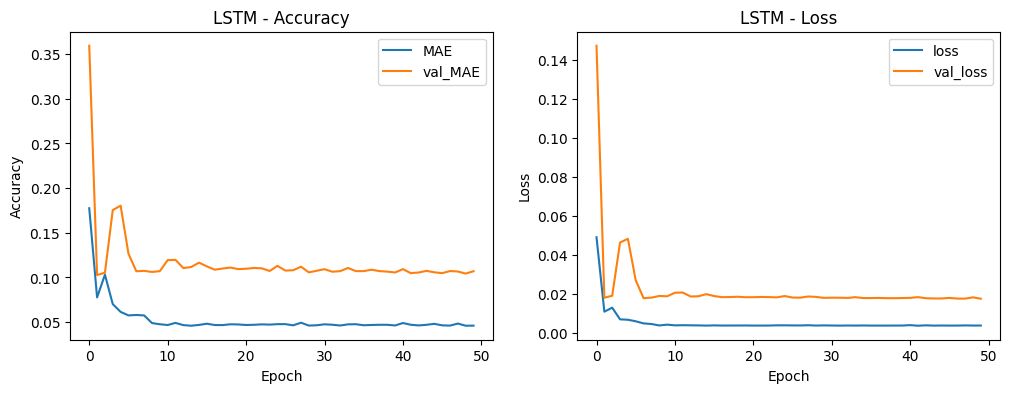

In [4]:
from tensorflow import keras
from tensorflow.keras import layers

# Define LSTM model
lstm_model = keras.Sequential([
    layers.Input(shape=(lookback, 1)),
    layers.LSTM(50, return_sequences=True, name="lstm_layer_1"),
    layers.LSTM(50, name="lstm_layer_2"),
    layers.Dense(1, name="output_layer")
])

# Compile the model
lstm_model.compile(optimizer='adam', loss='mse', metrics=['mean_absolute_error'])

# Train the model
history_lstm = lstm_model.fit(train_X, train_y, epochs=50, batch_size=32, validation_data=(test_X, test_y), verbose=1)
## Plotting loss and MAE
plot_training(history_lstm, "LSTM")


#### 3.1 LSTM Network Architecture

visualize the architecture of the LSTM model


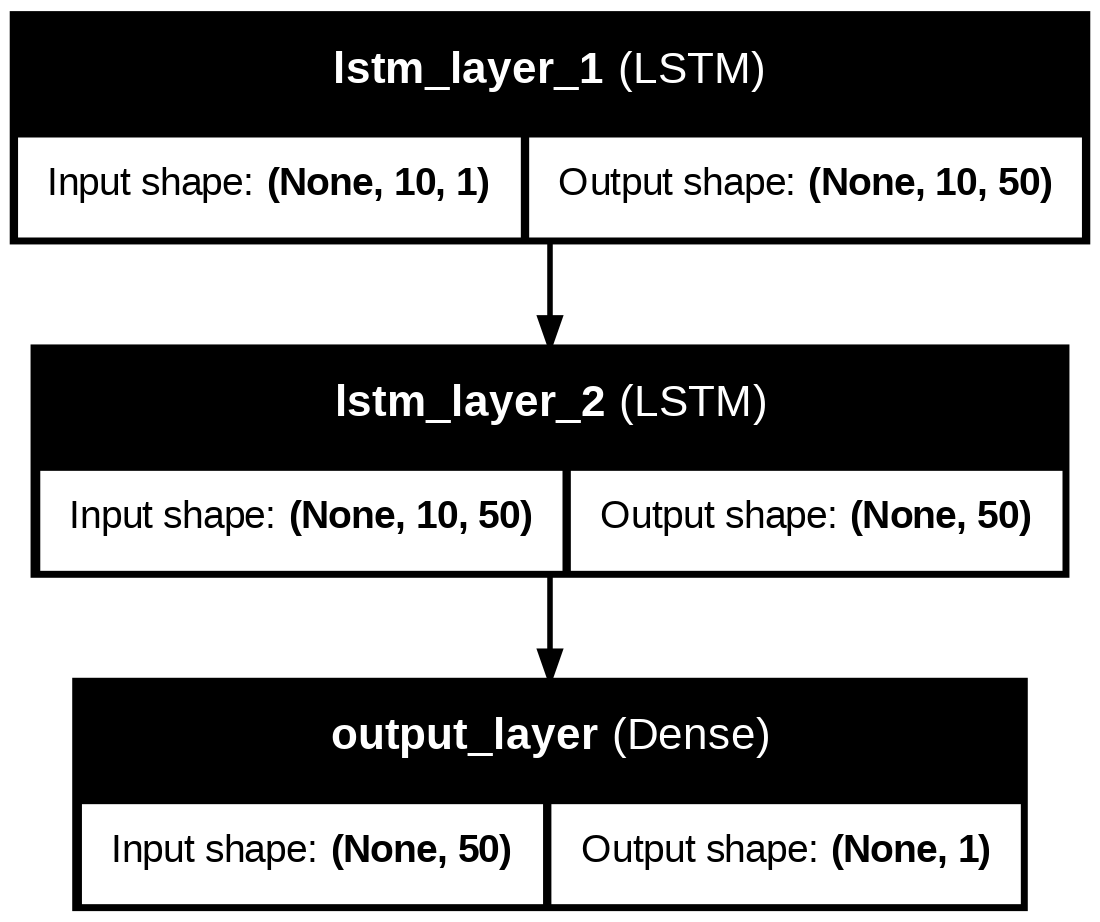

In [5]:
from tensorflow.keras.utils import plot_model

plot_model(lstm_model, to_file='lstm_model.png', show_shapes=True, show_layer_names=True)


#### 3.2 Evalution of LSTM model

In [6]:
# Evaluate LSTM model
lstm_predictions = lstm_model.predict(test_X)
lstm_predictions = scaler.inverse_transform(lstm_predictions)
test_y_original = scaler.inverse_transform(test_y.reshape(-1, 1))
lstm_mse = mean_squared_error(test_y_original, lstm_predictions)
lstm_mae = mean_absolute_error(test_y_original, lstm_predictions)
lstm_mape = mean_absolute_percentage_error(test_y_original, lstm_predictions)

print(f"LSTM Model - MSE: {lstm_mse}, MAE: {lstm_mae}, MAPE: {lstm_mape}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 338ms/step
LSTM Model - MSE: 12.702634680411858, MAE: 2.872997479742964, MAPE: 0.1476198345607472


#### 4. Bidirectional LSTM Model
 build a Bidirectional LSTM model, which improves the model's ability to learn from both past and future data.

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 189ms/step - loss: 0.0540 - mean_absolute_error: 0.1885 - val_loss: 0.0608 - val_mean_absolute_error: 0.2126
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0088 - mean_absolute_error: 0.0785 - val_loss: 0.0188 - val_mean_absolute_error: 0.1143
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0104 - mean_absolute_error: 0.0900 - val_loss: 0.0280 - val_mean_absolute_error: 0.1321
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0058 - mean_absolute_error: 0.0585 - val_loss: 0.0514 - val_mean_absolute_error: 0.1912
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0071 - mean_absolute_error: 0.0603 - val_loss: 0.0363 - val_mean_absolute_error: 0.1537
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0045 - mean_absolute_error: 0.0503 - val_loss: 0.0178 - val_mean_absolute_error: 0.1029
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0040 - mean_absolute_error: 0.0515 - val_loss: 0.0164 - va

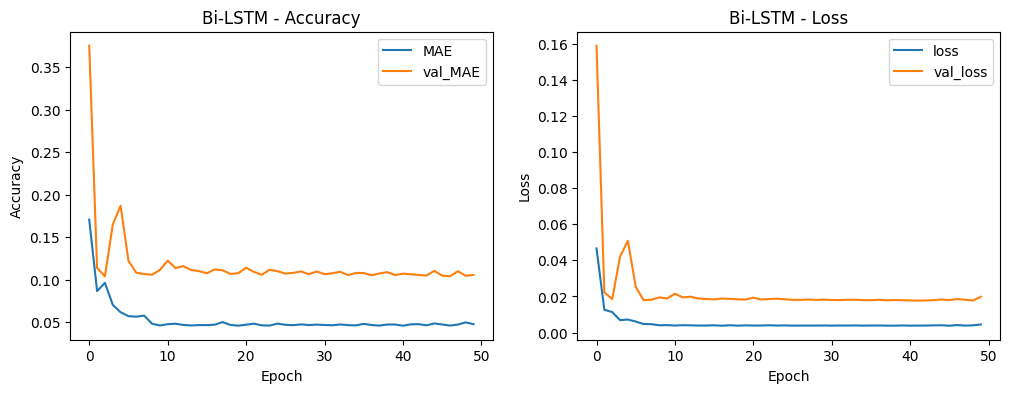

In [ ]:
# Define Bidirectional LSTM model
bi_lstm_model = keras.Sequential([
    layers.Input(shape=(lookback, 1)),
    layers.Bidirectional(layers.LSTM(50, return_sequences=True)),
    layers.LSTM(50),
    layers.Dense(1)
])

# Compile the model
bi_lstm_model.compile(optimizer='adam', loss='mse', metrics=['mean_absolute_error'])

# Train the model
history_bi_lstm = bi_lstm_model.fit(train_X, train_y, epochs=50, batch_size=32, validation_data=(test_X, test_y), verbose=1)

## Plotting loss and MAE
plot_training(history_lstm, "Bi-LSTM")



#### 4.1 Bidirectional LSTM Network Architecture
Visualizing the architecture of the Bidirectional LSTM model:

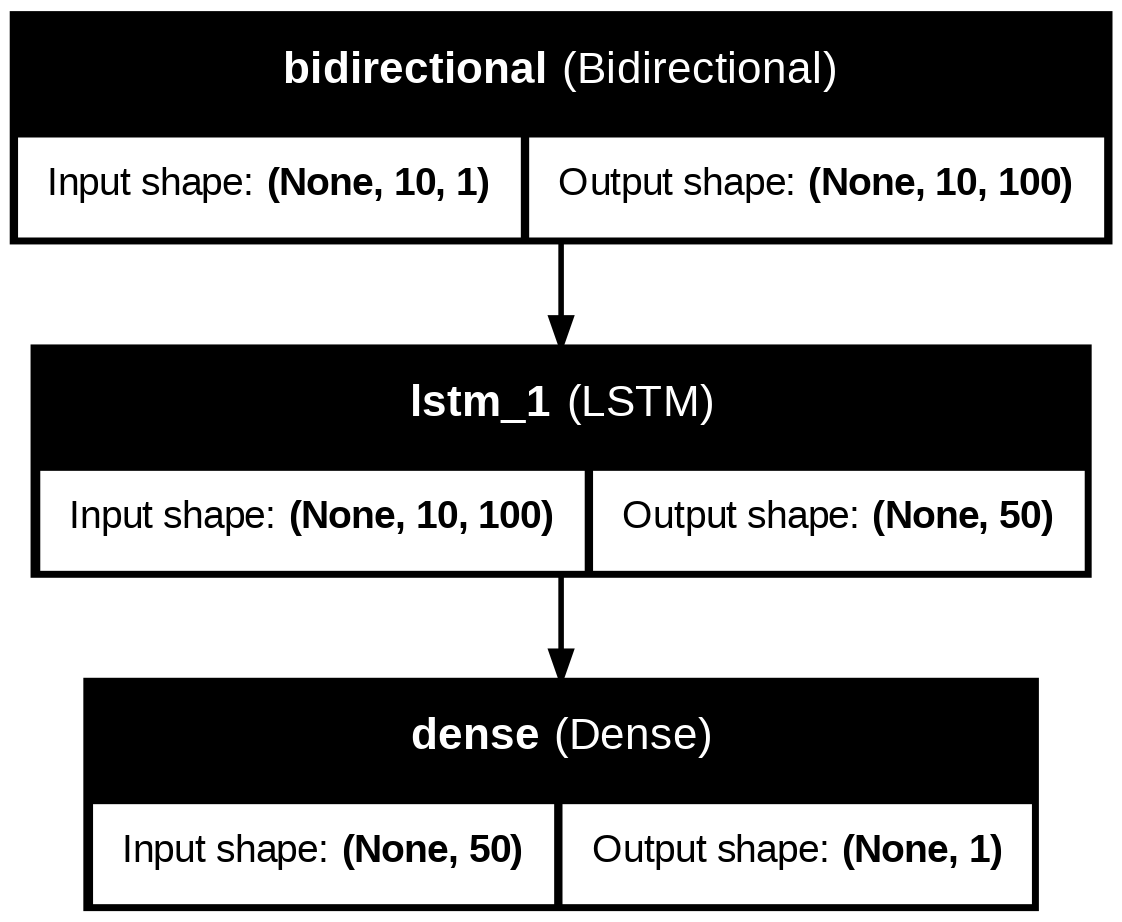

In [ ]:
plot_model(bi_lstm_model, to_file='bi_lstm_model.png', show_shapes=True, show_layer_names=True)


#### 4.2 Evalution of Bi-LSTM model

In [ ]:
# Evaluate Bi-LSTM model
bi_lstm_predictions = bi_lstm_model.predict(test_X)
bi_lstm_predictions = scaler.inverse_transform(bi_lstm_predictions)
test_y_original = scaler.inverse_transform(test_y.reshape(-1, 1))
bi_lstm_mse = mean_squared_error(test_y_original, bi_lstm_predictions)
bi_lstm_mae = mean_absolute_error(test_y_original, bi_lstm_predictions)
bi_lstm_mape = mean_absolute_percentage_error(test_y_original, bi_lstm_predictions)

print(f"Bi-LSTM Model - MSE: {bi_lstm_mse}, MAE: {bi_lstm_mae}, MAPE: {bi_lstm_mape}")

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 473ms/step
Bi-LSTM Model - MSE: 11.60617532665853, MAE: 2.662316462211788, MAPE: 0.1337080436706895


#### 5. GRU Model
GRU (Gated Recurrent Unit) model , which is often used as an alternative to LSTM for faster training times with similar performance.

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - loss: 0.0586 - mean_absolute_error: 0.1982 - val_loss: 0.2201 - val_mean_absolute_error: 0.4490
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0222 - mean_absolute_error: 0.1153 - val_loss: 0.0981 - val_mean_absolute_error: 0.2852
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0100 - mean_absolute_error: 0.0793 - val_loss: 0.0409 - val_mean_absolute_error: 0.1677
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0109 - mean_absolute_error: 0.0904 - val_loss: 0.0287 - val_mean_absolute_error: 0.1397
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0108 - mean_absolute_error: 0.0909 - val_loss: 0.0355 - val_mean_absolute_error: 0.1576
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0073 - mean_absolute_error: 0.0732 - val_loss: 0.0447 - val_mean_absolute_error: 0.1794
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0059 - mean_absolute_error: 0.0629 - val_loss: 0.0495 - va

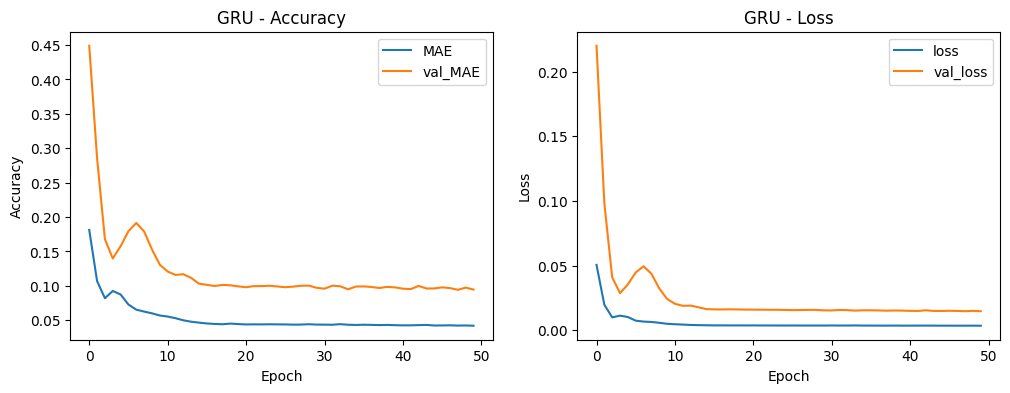

In [ ]:
# Define GRU model
gru_model = keras.Sequential([
    layers.Input(shape=(lookback, 1)),
    layers.GRU(50),
    layers.Dense(1)
])

# Compile the model
gru_model.compile(optimizer='adam', loss='mse', metrics=['mean_absolute_error'])

# Train the model
history_gru = gru_model.fit(train_X, train_y, epochs=50, batch_size=32, validation_data=(test_X, test_y), verbose=1)

# Plotting loss
plot_training(history_gru, "GRU")


#### 5.1 GRU Network Architecture
Visualizing the architecture of the GRU model:

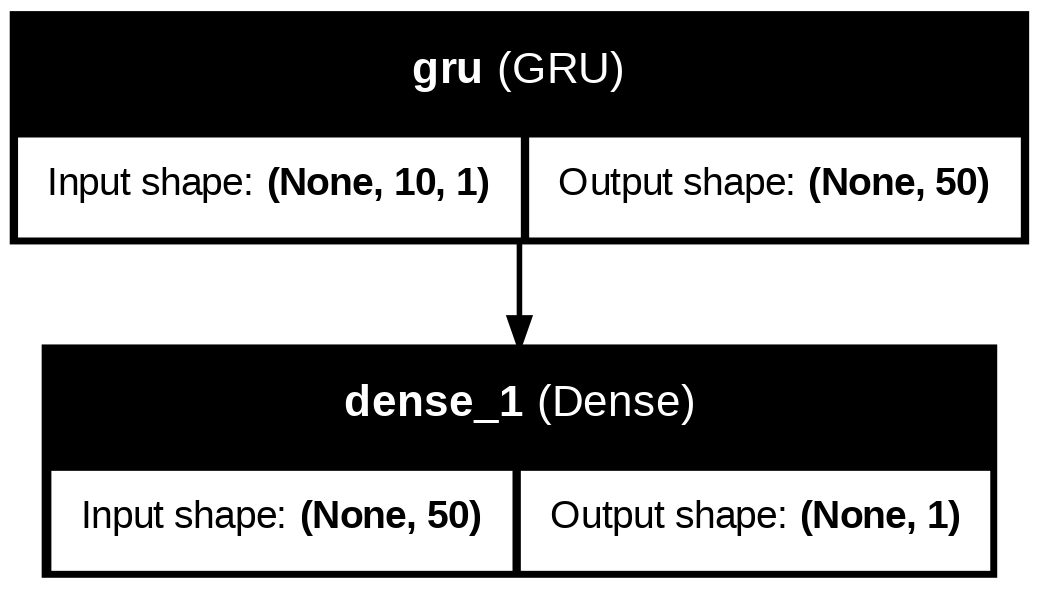

In [ ]:
plot_model(gru_model, to_file='gru_model.png', show_shapes=True, show_layer_names=True)


#### 5.2 Evalution of GRU model

In [ ]:
# Evaluate GRU model
gru_predictions = gru_model.predict(test_X)
gru_predictions = scaler.inverse_transform(gru_predictions)
test_y_original = scaler.inverse_transform(test_y.reshape(-1, 1))
gru_mse = mean_squared_error(test_y_original, gru_predictions)
gru_mae = mean_absolute_error(test_y_original, gru_predictions)
gru_mape = mean_absolute_percentage_error(test_y_original, gru_predictions)

print(f"GRU Model - MSE: {gru_mse}, MAE: {gru_mae}, MAPE: {gru_mape}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
GRU Model - MSE: 10.590544771073903, MAE: 2.539592105772736, MAPE: 0.1303273930591716


#### 6. CNN-LSTM Model
 build a CNN-LSTM model, which combines Convolutional layers for feature extraction and LSTM for sequence learning.

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.0591 - mean_absolute_error: 0.1986 - val_loss: 0.2175 - val_mean_absolute_error: 0.4450
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0199 - mean_absolute_error: 0.1046 - val_loss: 0.0756 - val_mean_absolute_error: 0.2393
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0086 - mean_absolute_error: 0.0766 - val_loss: 0.0213 - val_mean_absolute_error: 0.1119
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0114 - mean_absolute_error: 0.0962 - val_loss: 0.0205 - val_mean_absolute_error: 0.1101
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0089 - mean_absolute_error: 0.0827 - val_loss: 0.0341 - val_mean_absolute_error: 0.1434
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0064 - mean_absolute_error: 0.0647 - val_loss: 0.0456 - val_mean_absolute_error: 0.1731
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0066 - mean_absolute_error: 0.0595 - val_loss: 0.0389 - va

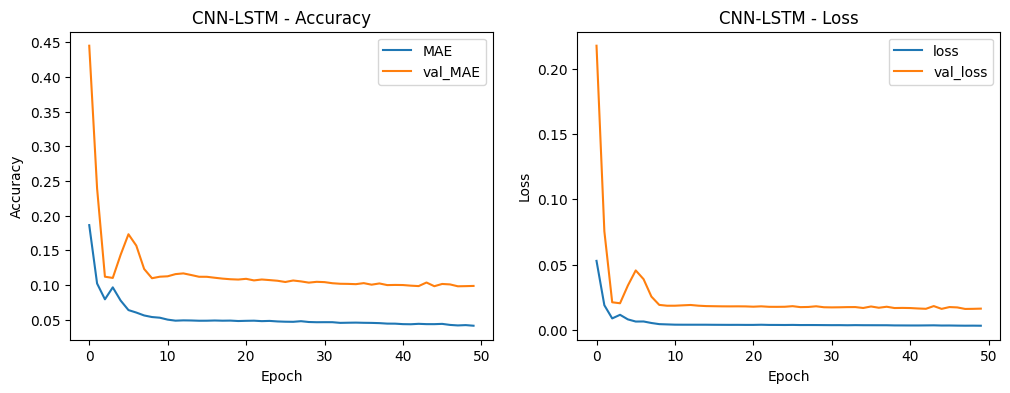

In [ ]:
# Define CNN-LSTM model
cnn_lstm_model = keras.Sequential([
    layers.Input(shape=(lookback, 1)),
    layers.Conv1D(filters=64, kernel_size=3, activation='relu'),
    layers.MaxPooling1D(pool_size=2),
    layers.LSTM(50),
    layers.Dense(1)
])

# Compile the model
cnn_lstm_model.compile(optimizer='adam', loss='mse', metrics=['mean_absolute_error'])

# Train the model
history_cnn_lstm = cnn_lstm_model.fit(train_X, train_y, epochs=50, batch_size=32, validation_data=(test_X, test_y), verbose=1)

# Plotting loss
plot_training(history_cnn_lstm, "CNN-LSTM")


#### 6.1 CNN-LSTM Network Architecture
Visualize the CNN-LSTM model architecture

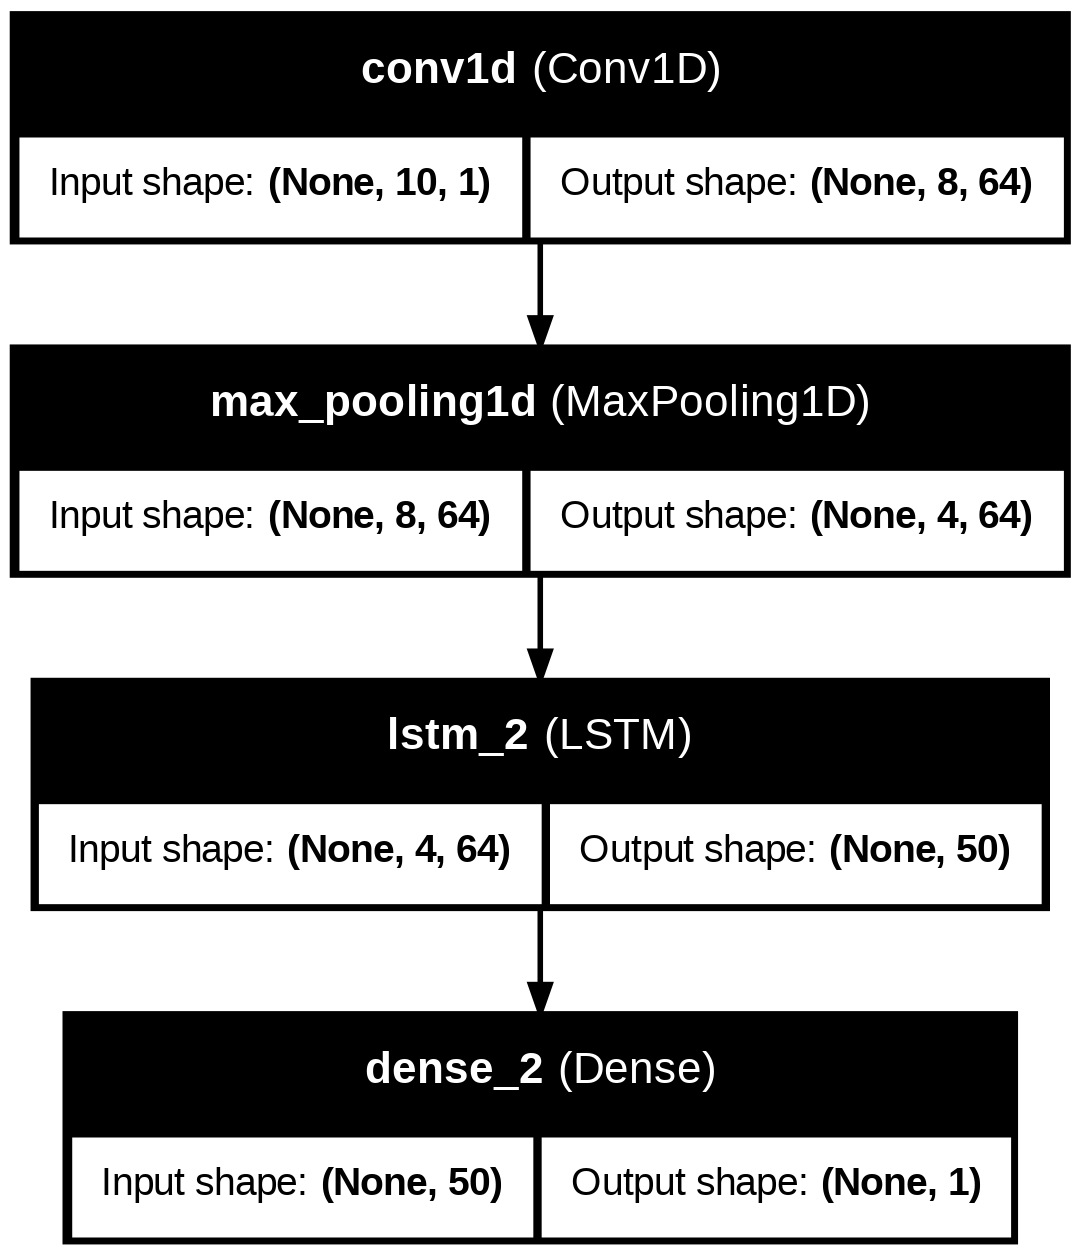

In [ ]:
plot_model(cnn_lstm_model, to_file='cnn_lstm_model.png', show_shapes=True, show_layer_names=True)


#### 6.2 Evaluation and Summary

In [ ]:
# Evaluate CNN-LSTM model
cnn_lstm_predictions = cnn_lstm_model.predict(test_X)
cnn_lstm_predictions = scaler.inverse_transform(cnn_lstm_predictions)
test_y_original = scaler.inverse_transform(test_y.reshape(-1, 1))
cnn_lstm_mse = mean_squared_error(test_y_original, cnn_lstm_predictions)
cnn_lstm_mae = mean_absolute_error(test_y_original, cnn_lstm_predictions)
cnn_lstm_mape = mean_absolute_percentage_error(test_y_original, cnn_lstm_predictions)

print(f"CNN-LSTM Model - MSE: {cnn_lstm_mse}, MAE: {cnn_lstm_mae}, MAPE: {cnn_lstm_mape}")




2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
CNN-LSTM Model - MSE: 11.831203567855278, MAE: 2.6472818397142297, MAPE: 0.1284037786944725


#### 7. Model Comparsion

LSTM Model - MSE: 14.2699, MAE: 2.8366, MAPE: 0.14%
Bi-LSTM Model - MSE: 11.6062, MAE: 2.6623, MAPE: 0.13%
GRU Model - MSE: 10.5905, MAE: 2.5396, MAPE: 0.13%
CNN-LSTM Model - MSE: 11.8312, MAE: 2.6473, MAPE: 0.13%


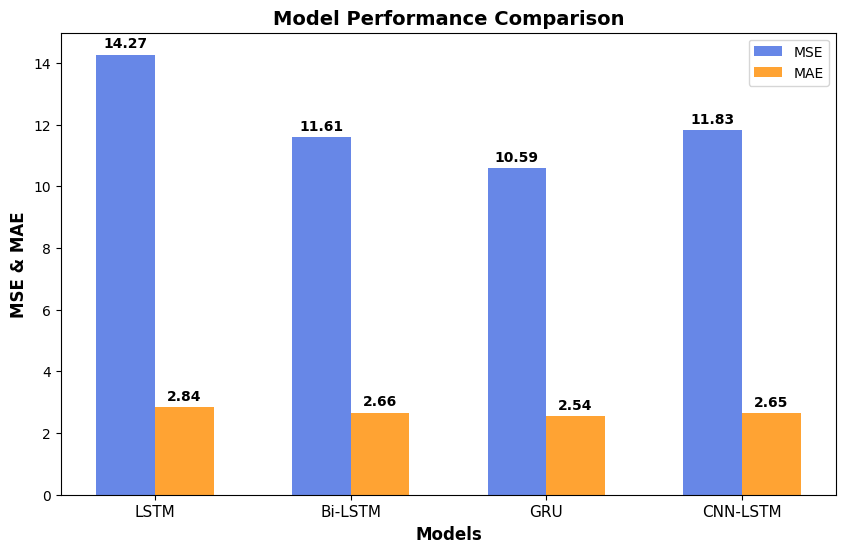

In [ ]:
# Dictionary to store model performance metrics
model_performance = {
    "LSTM": {"MSE": lstm_mse, "MAE":lstm_mae, "MAPE":lstm_mape},
    "Bi-LSTM":{"MSE": bi_lstm_mse, "MAE":bi_lstm_mae, "MAPE":bi_lstm_mape},
    "GRU":{"MSE": gru_mse, "MAE":gru_mae, "MAPE":gru_mape},
    "CNN-LSTM":{"MSE": cnn_lstm_mse, "MAE":cnn_lstm_mae, "MAPE":cnn_lstm_mape},
}

# Print formatted model performance
for model, metrics in model_performance.items():
    print(f"{model} Model - MSE: {metrics['MSE']:.4f}, MAE: {metrics['MAE']:.4f}, MAPE: {metrics['MAPE']:.2f}%")

# Extract data
models = list(model_performance.keys())
mse_values = [model_performance[m]["MSE"] for m in models]
mae_values = [model_performance[m]["MAE"] for m in models]
mape_values = [model_performance[m]["MAPE"] for m in models]

x = np.arange(len(models))  # X-axis positions
width = 0.3  # Bar width

fig, ax = plt.subplots(figsize=(10, 6))

# Plot MSE & MAE bars
bars1 = ax.bar(x - width/2, mse_values, width, label='MSE', color='royalblue', alpha=0.8)
bars2 = ax.bar(x + width/2, mae_values, width, label='MAE', color='darkorange', alpha=0.8)

# Set labels and title
ax.set_xlabel("Models", fontsize=12, fontweight='bold')
ax.set_ylabel("MSE & MAE", fontsize=12, fontweight='bold')
ax.set_title("Model Performance Comparison", fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)

# Display values on top of bars
def add_values(bars, ax):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha='center', fontsize=10, fontweight='bold')

add_values(bars1, ax)
add_values(bars2, ax)

# Add legend
ax.legend()

# Show plot
plt.show()


#### 7.1 Model performance Analysis:

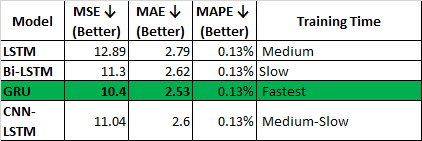

### 8. Conclusion:
- GRU performs the best overall with the minimum MAE (2.53) and MSE (10.40).
Most suitable for time-series forecasting due to its efficiency in handling sequential dependencies.

- The second-best performing model is CNN-LSTM, slightly behind GRU for both MAE and MSE.
Most suitable for complex feature extraction work since CNN layers are able to handle spatial features before LSTM handling.

- LSTM produces the biggest error values but remains a solid baseline model.
Not the best choice for this data compared to GRU or CNN-LSTM.

- Bi-LSTM is not greatly superior to LSTM even with bidirectional processing.
If computational capacity is a problem, Bi-LSTM is not worth extra complexity.